In [1]:
!pip install spacy scikit-learn pandas openpyxl -q
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:

nlp = spacy.load("en_core_web_sm")

In [2]:
import pandas as pd
import re
import spacy
import hashlib

In [4]:
df = pd.read_excel("/content/edufeed_clean_data.xlsx")

In [5]:
def generate_hash(text):
    return hashlib.sha256(text.encode()).hexdigest()

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


In [9]:
student_pii = ['student_name', 'email', 'roll_no', 'user_id']
df.drop(columns=[c for c in student_pii if c in df.columns], inplace=True)

In [10]:
df['student_id'] = pd.Series(df.index.astype(str)).apply(generate_hash)

In [11]:
def mask_student_info(text):
    if pd.isna(text) or text == '':
        return ''

    text = str(text)
    doc = nlp(text)

    for ent in doc.ents:
        if ent.label_ == 'PERSON':
            text = text.replace(ent.text, '[STUDENT]')

    text = re.sub(r'\b\d{2}[A-Z]{2}\d{3,4}\b', '[ROLL]', text)
    text = re.sub(r'[\w\.-]+@[\w\.-]+\.\w+', '[EMAIL]', text)

    return text

df['comment_masked'] = df['comments'].apply(mask_student_info)
df.drop(columns=['comments'], inplace=True)

In [12]:
def get_sentiment(star):
    if star >= 4:
        return 'Positive'
    elif star >= 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['student_star'].apply(get_sentiment)

In [13]:
X = df['comment_masked'].fillna('').astype(str)
y = df['sentiment']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = model.predict(X_test_vec)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7695771828871654
              precision    recall  f1-score   support

    Negative       0.76      0.72      0.74      1134
     Neutral       0.39      0.08      0.13       501
    Positive       0.79      0.94      0.86      2362

    accuracy                           0.77      3997
   macro avg       0.65      0.58      0.58      3997
weighted avg       0.73      0.77      0.73      3997



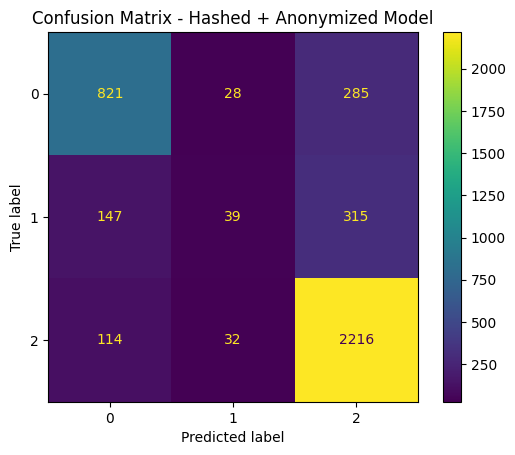

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Hashed + Anonymized Model")
plt.show()

In [20]:
results = pd.DataFrame({
    'Review': X_test,
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.sample(10))

                                                  Review    Actual Predicted
14913  GYM is AWESOM!! He let us play games in class ...  Positive  Negative
19206  Labarge is the man. There is some reading to d...  Positive  Positive
16896                                        No Comments  Positive  Positive
2902   She was a good teacher, but I felt that she fo...   Neutral  Positive
10441  Tulovsky is the best teacher at St. Johns. Tea...  Positive  Positive
10984  Good class, as long as you show up and pay att...  Positive  Positive
13073  Professor [STUDENT] gives extra credit so if y...   Neutral  Positive
15629  REALLY smart guy! He\'s done this for a long t...  Positive  Positive
19460                                        No Comments   Neutral  Positive
11290                                so knowledgeable!!!  Positive  Positive


In [23]:
review = input("Enter your review: ")

student_id, masked_review, sentiment = process_new_review(review)

print("\nOutput:")
print("Student ID:", student_id)
print("Masked Review:", masked_review)
print("Sentiment:", sentiment)

Enter your review: sss
Student ID: a871c47a7f48a12b38a994e48a9659fab5d6376f3dbce37559bcb617efe8662d
Masked Review: sss
Sentiment: Negative

Output:
Student ID: a871c47a7f48a12b38a994e48a9659fab5d6376f3dbce37559bcb617efe8662d
Masked Review: sss
Sentiment: Negative
